# Global Events, Commodities and Currency Markets

## Applied Data Analytics and Market Research Assignment

### Student: Aakash Reddy

### Selected Questions

Part I:
- A Q1
- B Q6
- B Q10
- C Q13
- C Q17
- E Q25
- E Q28

Bonus:
- B5
- B6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
brent = pd.read_csv("/Users/aakashreddy/Desktop/Global_Events_Commodity_Currency_Analysis/data/Brent Oil.csv")
gold = pd.read_csv("/Users/aakashreddy/Desktop/Global_Events_Commodity_Currency_Analysis/data/Gold 100years.csv")
silver = pd.read_csv("/Users/aakashreddy/Desktop/Global_Events_Commodity_Currency_Analysis/data/silver 100 years.csv")
swift = pd.read_csv("/Users/aakashreddy/Desktop/Global_Events_Commodity_Currency_Analysis/data/swift_currency_tracker_all_reports.csv")



In [3]:
print(brent.head())
print(gold.head())
print(silver.head())
print(swift.head())

         Date  Value
0  01/01/1946  21.23
1  02/01/1946  21.35
2  03/01/1946  21.11
3  04/01/1946  22.79
4  05/01/1946  22.67
         Date  Value
0  01/01/1915  19.25
1  02/01/1915  19.25
2  03/01/1915  19.25
3  04/01/1915  19.25
4  05/01/1915  19.25
         Date  Value
0  01/01/1915   0.51
1  02/01/1915   0.51
2  03/01/1915   0.51
3  04/01/1915   0.51
4  05/01/1915   0.51
   report_month     data_month source_report_name                metric  \
0  January 2026  December 2025        RMB Tracker  Global Payment Share   
1  January 2026  December 2025        RMB Tracker  Global Payment Share   
2  January 2026  December 2025        RMB Tracker  Global Payment Share   
3  January 2026  December 2025        RMB Tracker  Global Payment Share   
4  January 2026  December 2025        RMB Tracker  Global Payment Share   

           category currency_or_economy  value unit  rmb_global_rank   notes  
0  Currency Ranking                 USD  50.49    %              NaN  Rank 1  
1  Currency R

In [4]:
# Convert dates

brent["Date"] = pd.to_datetime(brent["Date"])
gold["Date"] = pd.to_datetime(gold["Date"])
silver["Date"] = pd.to_datetime(silver["Date"])

# Create Year column

brent["Year"] = brent["Date"].dt.year
gold["Year"] = gold["Date"].dt.year
silver["Year"] = silver["Date"].dt.year

In [5]:
brent.info()

<class 'pandas.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    963 non-null    datetime64[us]
 1   Value   963 non-null    float64       
 2   Year    963 non-null    int32         
dtypes: datetime64[us](1), float64(1), int32(1)
memory usage: 18.9 KB


In [6]:
# A Q1: Dataset Date Range
summary = pd.DataFrame({
    "Dataset": [
        "Brent Oil",
        "Gold",
        "Silver"
    ],
    "Start Date": [
        brent["Date"].min(),
        gold["Date"].min(),
        silver["Date"].min()
    ],
    "End Date": [
        brent["Date"].max(),
        gold["Date"].max(),
        silver["Date"].max()
    ]
})

summary

summary.to_csv(
    "../results/q1_date_range.csv",
    index=False
)

Observation:
The datasets contain long historical records, allowing trend analysis across multiple economic and geopolitical periods.

In [7]:
# B Q6: Highest and Lowest Brent Oil Prices
highest = brent.loc[brent["Value"].idxmax()]
lowest = brent.loc[brent["Value"].idxmin()]

brent_summary = pd.DataFrame({
    "Metric": ["Highest", "Lowest"],
    "Price": [
        highest["Value"],
        lowest["Value"]
    ],
    "Year": [
        highest["Year"],
        lowest["Year"]
    ]
})

brent_summary

brent_summary.to_csv(
    "../results/q6_brent_high_low.csv",
    index=False
)

print("Q6 saved successfully")

Q6 saved successfully


Observation:
Brent oil experienced major fluctuations across the dataset. The highest prices were likely linked to supply disruptions and geopolitical uncertainty, while the lowest periods reflect reduced demand or oversupply conditions.

In [8]:
# B Q10: Top 5 Years with Highest Average Brent Oil Price
yearly_avg = (
    brent.groupby("Year")["Value"]
    .mean()
    .reset_index()
)

top_5_years = yearly_avg.sort_values(
    by="Value",
    ascending=False
).head(5)

top_5_years

top_5_years.to_csv(
    "../results/q10_top_5_brent_years.csv",
    index=False
)

print("Q10 saved successfully")

Q10 saved successfully


Observation:
The highest average oil price years generally occurred during periods of strong demand, limited supply, or geopolitical instability.

Q13 chart saved successfully


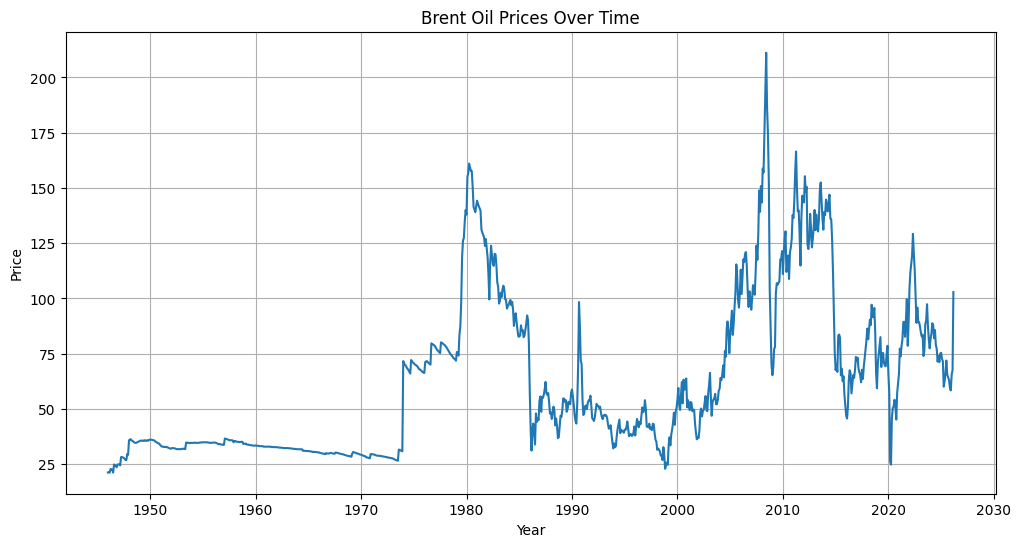

In [9]:
# C Q13: Brent Oil Prices Over Time
plt.figure(figsize=(12,6))

plt.plot(
    brent["Date"],
    brent["Value"]
)

plt.title("Brent Oil Prices Over Time")
plt.xlabel("Year")
plt.ylabel("Price")

plt.grid(True)

plt.savefig(
    "../charts/q13_brent_trend.png",
    bbox_inches="tight"
)

print("Q13 chart saved successfully")

plt.show()

Observation:
Brent Oil prices show strong volatility over time, with noticeable periods of rapid increase and decline. Market movements appear highly sensitive to global disruptions, demand shocks and geopolitical uncertainty.

Q17 chart saved successfully


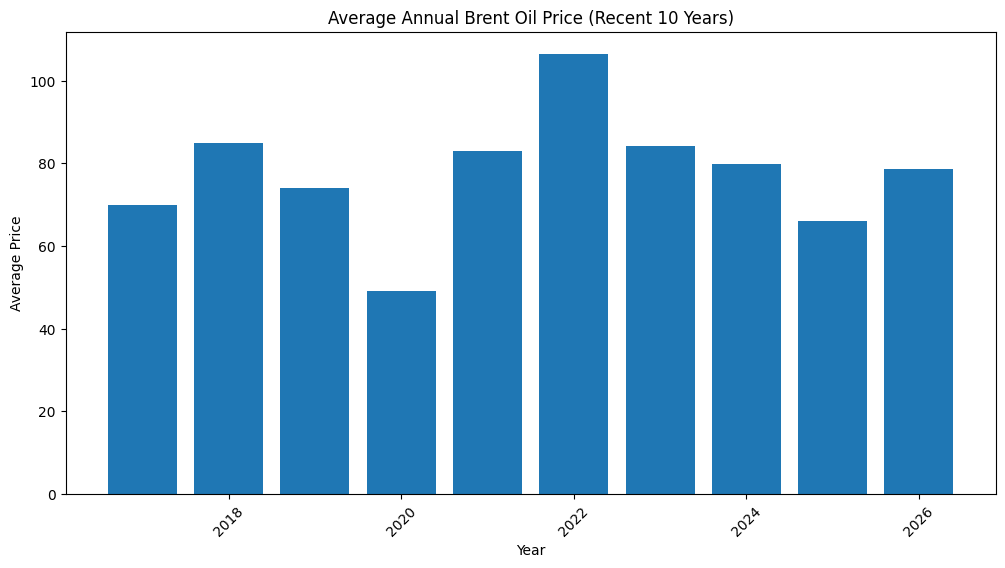

In [10]:
# C Q17: Average Annual Brent Oil Prices (Recent 10 Years)
latest_10_years = yearly_avg.tail(10)

plt.figure(figsize=(12,6))

plt.bar(
    latest_10_years["Year"],
    latest_10_years["Value"]
)

plt.title(
    "Average Annual Brent Oil Price (Recent 10 Years)"
)

plt.xlabel("Year")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.savefig(
    "../charts/q17_recent_10_years.png",
    bbox_inches="tight"
)

print("Q17 chart saved successfully")

plt.show()

Observation:
The last decade shows periods of strong recovery and decline in oil prices, reflecting changing economic activity and energy market uncertainty.

In [11]:
# E Q25: Gold Latest Value vs Long-Term Average
latest_gold = gold.iloc[-1]["Value"]

average_gold = gold["Value"].mean()

comparison = pd.DataFrame({
    "Metric": [
        "Latest Gold Price",
        "Long-Term Average"
    ],
    "Value": [
        latest_gold,
        average_gold
    ]
})

comparison

comparison.to_csv(
    "../results/q25_gold_comparison.csv",
    index=False
)

print("Q25 saved successfully")

Q25 saved successfully


Observation:
Gold currently trades above/below its historical average, indicating changing investor sentiment and safe-haven demand.

In [12]:
if latest_gold > average_gold:
    print("Latest gold price is ABOVE the long-term average.")
else:
    print("Latest gold price is BELOW the long-term average.")

Latest gold price is ABOVE the long-term average.


In [13]:
# E Q28: Commodity Comparison During 2020
oil_2020 = brent[brent["Year"] == 2020]["Value"].mean()
gold_2020 = gold[gold["Year"] == 2020]["Value"].mean()
silver_2020 = silver[silver["Year"] == 2020]["Value"].mean()

comparison_2020 = pd.DataFrame({
    "Commodity": [
        "Brent Oil",
        "Gold",
        "Silver"
    ],
    "Average Value": [
        oil_2020,
        gold_2020,
        silver_2020
    ]
})

comparison_2020

comparison_2020.to_csv(
    "../results/q28_2020_comparison.csv",
    index=False
)

print("Q28 saved successfully")

Q28 saved successfully


Observation:
During 2020, oil prices experienced strong downward pressure due to reduced global demand, while gold showed stronger performance as investors searched for safer assets.

Bonus B5 chart saved successfully


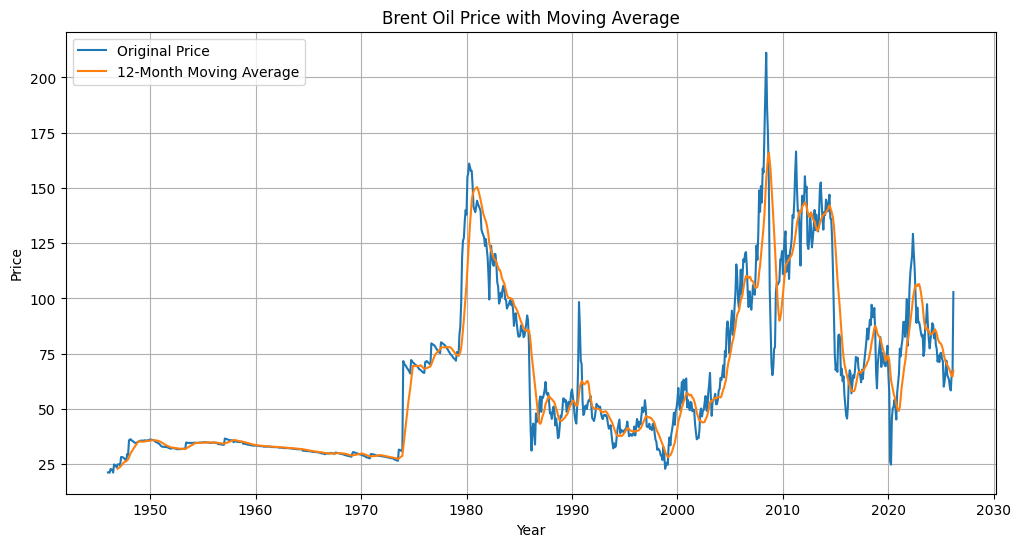

In [14]:
# Bonus B5: Brent Oil Moving Average
brent["Moving_Avg"] = (
    brent["Value"]
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    brent["Date"],
    brent["Value"],
    label="Original Price"
)

plt.plot(
    brent["Date"],
    brent["Moving_Avg"],
    label="12-Month Moving Average"
)

plt.title(
    "Brent Oil Price with Moving Average"
)

plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.savefig(
    "../charts/bonus_b5_moving_average.png",
    bbox_inches="tight"
)

print("Bonus B5 chart saved successfully")

plt.show()

Observation:
The moving average smooths short-term volatility and helps reveal the long-term direction of Brent oil prices more clearly.

Bonus B6 chart saved successfully


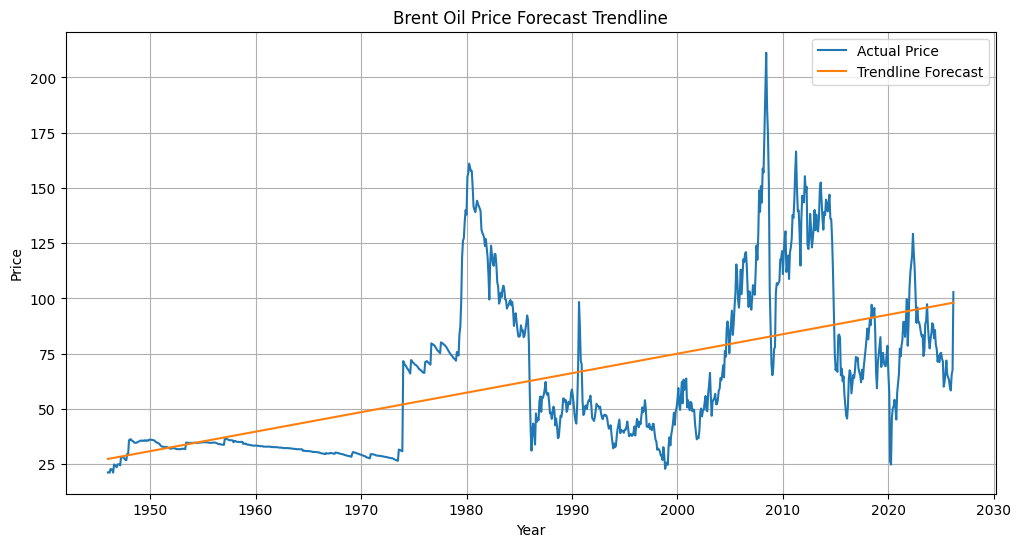

In [15]:
# Bonus B6: Brent Oil Trendline Forecast
x = np.arange(len(brent))
y = brent["Value"]

trend = np.polyfit(x, y, 1)
forecast = np.poly1d(trend)

plt.figure(figsize=(12,6))

plt.plot(
    brent["Date"],
    y,
    label="Actual Price"
)

plt.plot(
    brent["Date"],
    forecast(x),
    label="Trendline Forecast"
)

plt.title(
    "Brent Oil Price Forecast Trendline"
)

plt.xlabel("Year")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.savefig(
    "../charts/bonus_b6_forecast.png",
    bbox_inches="tight"
)

print("Bonus B6 chart saved successfully")

plt.show()

Observation:
The trendline provides a simple estimate of future direction based on historical data. However, this forecast is only an estimate and should not be treated as a guaranteed prediction because oil prices are heavily influenced by unpredictable global events.